## Quântica Aplicada

Prof. Luciano T. Costa \
Departamento de Físico-Química \
Sala 309 \
e-mail: ltcosta@id.uff.br \
MolMod-CS: www.molmodcs.uff.br \
Facebook: https://www.facebook.com/molmodcs \
Linkedin: https://www.linkedin.com/in/luciano-t-costa-90a85a164/

## **Prática 1: "Átomo de Hidrogênio"**

Realizar um cálculo Hartree-Fock no ORCA variando a função base em: STO-3G,3-21G, 6-31G e 6-311G. Observar a convergência da energia para o valor exato de -0.5 hartree quando aumentamos a função base.

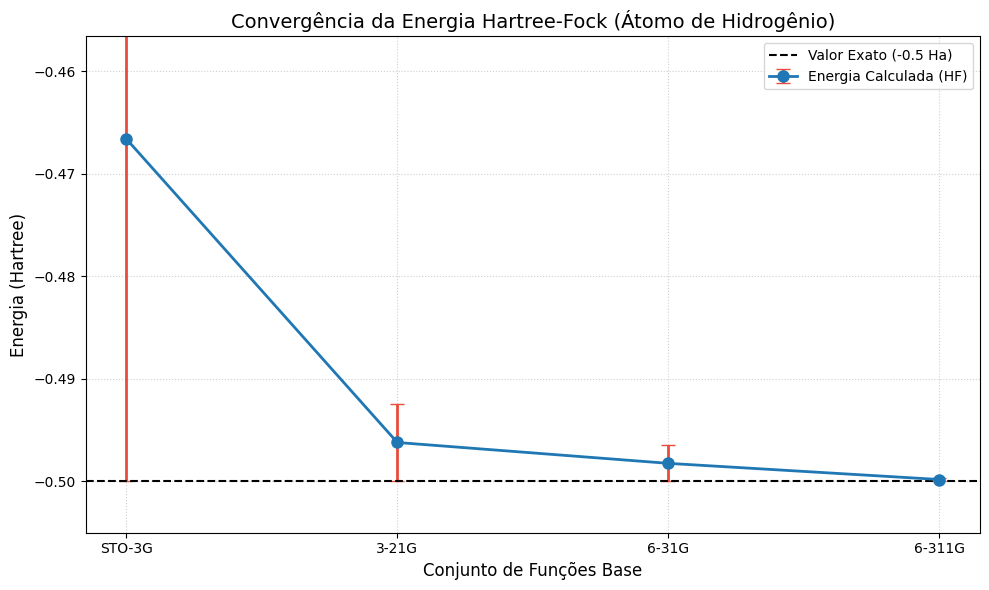

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carregar os dados
# O padrão universal permite uma leitura simples sem parâmetros extras
df = pd.read_csv('data.csv')

# 2. Organização dos Dados
# Filtramos as funções base para o plot e extraímos o valor exato para a referência
df_calc = df[df['basis_set'] != 'EXATO'].copy()
valor_exato = df[df['basis_set'] == 'EXATO']['E(hartree)'].values[0]

# 3. Configuração do Gráfico
plt.figure(figsize=(10, 6))

# Plot com barras de erro usando o desvio absoluto
plt.errorbar(
    df_calc['basis_set'],
    df_calc['E(hartree)'],
    yerr=df_calc['Desvio_abs'],
    fmt='o-',           # Marcadores redondos conectados por linha
    capsize=5,          # Alças horizontais nas barras de erro
    color='#1f77b4',    # Azul sólido
    ecolor='#e74c3c',   # Barras de erro em vermelho para contraste
    linewidth=2,
    markersize=8,
    label='Energia Calculada (HF)'
)

# Marco da Referência Analítica (-0.5 Hartree)
plt.axhline(
    y=valor_exato,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Valor Exato ({valor_exato} Ha)'
)

# 4. Ajustes de Escala e Estética
# Definimos o limite para focar na convergência das bases maiores
plt.ylim(valor_exato - 0.005, df_calc['E(hartree)'].max() + 0.01)

plt.title('Convergência da Energia Hartree-Fock (Átomo de Hidrogênio)', fontsize=14)
plt.xlabel('Conjunto de Funções Base', fontsize=12)
plt.ylabel('Energia (Hartree)', fontsize=12)

# Adiciona grade suave para facilitar a leitura dos valores
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# 5. Finalização e Exibição
plt.tight_layout()
plt.show()